# CS3244 Group 17 Project: IMDb Spoiler Detection from Movie Reviews

This notebook presents an end-to-end workflow for binary spoiler classification using IMDb review text.

Workflow: setup and data loading, exploratory data analysis (EDA), data cleaning and preprocessing, data splitting, feature engineering, model training and model evaluation.

## 0. Setup and Data Loading

In [1]:
# imports
import pandas as pd
import numpy as np
import joblib, re, html, unicodedata
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import sparse
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm

C:\Users\darre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Read review dataset
df = pd.read_json("IMDB_reviews.json", lines=True)

In [3]:
# Read movies dataset
df_movies = pd.read_json("IMDB_movie_details.json", lines=True)

In [4]:
# df_master = pd.read_json("../Project/IMDB_reviews_train.json", lines=True)

## 1. Exploratory Data Analysis

### 1.1 EDA of reviews dataset

In [5]:
# Check details of reviews dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 573913 entries, 0 to 573912
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   review_date     573913 non-null  str  
 1   movie_id        573913 non-null  str  
 2   user_id         573913 non-null  str  
 3   is_spoiler      573913 non-null  bool 
 4   review_text     573913 non-null  str  
 5   rating          573913 non-null  int64
 6   review_summary  573913 non-null  str  
dtypes: bool(1), int64(1), str(5)
memory usage: 26.8 MB


In [6]:
print(df.isnull().sum())
# No sign of missing entries initially, but requires further checks into empty strings

review_date       0
movie_id          0
user_id           0
is_spoiler        0
review_text       0
rating            0
review_summary    0
dtype: int64


In [7]:
print(df.shape)
# 573,913 reviews, 7 features

(573913, 7)


In [8]:
print(df.columns)

Index(['review_date', 'movie_id', 'user_id', 'is_spoiler', 'review_text',
       'rating', 'review_summary'],
      dtype='str')


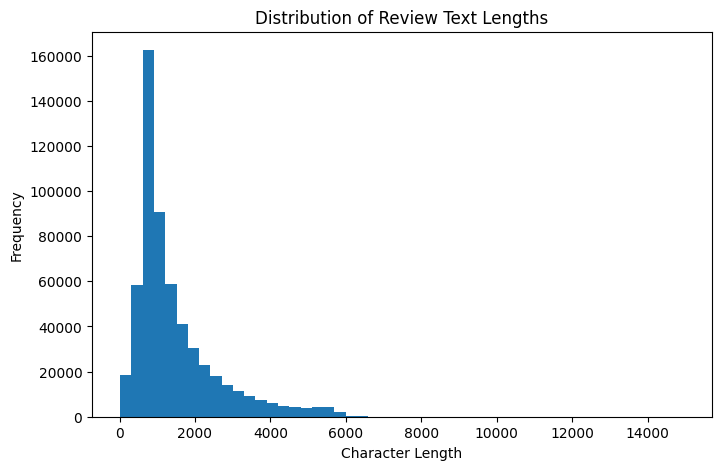

count    573913.000000
mean       1460.553525
std        1125.577019
min          18.000000
25%         719.000000
50%        1052.000000
75%        1815.000000
max       14963.000000
Name: review_text, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["review_text"].str.len(), bins=50)
plt.title("Distribution of Review Text Lengths")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()
print(df["review_text"].str.len().describe())
# Mean character length is 1460, relatively large inputs

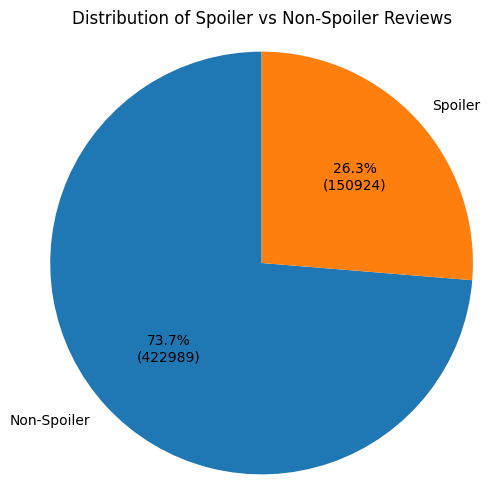

In [10]:
spoiler_counts = df["is_spoiler"].value_counts()
spoiler_labels = ["Non-Spoiler", "Spoiler"]

def autopct_format(pct):
    total = spoiler_counts.sum()
    count = int(round(pct * total / 100))
    return f"{pct:.1f}%\n({count})"

plt.figure(figsize=(6, 6))
plt.pie(
    spoiler_counts,
    labels = spoiler_labels,
    autopct = autopct_format,
    startangle = 90
)

plt.title("Distribution of Spoiler vs Non-Spoiler Reviews")
plt.axis("equal")
plt.show()
# Dataset is slightly imbalanced (73.7% non-spoiler vs 26.3% spoiler)

In [11]:
print((df["review_text"].str.strip() == "").sum())
# No empty or whitespace-only reviews detected, so no need for removal of trivial empty entries

0


In [12]:
print(df.duplicated(subset=["review_text"]).sum())
# 528 duplicate review texts, redundant samples that may cause bias or data leakage if not removed

528


In [13]:
dup_text = df[df.duplicated(subset=["review_text"], keep=False)]
dup_text.groupby("review_text").size().sort_values(ascending=False).head(6)
# Some duplicated text are quite long, indicating repeated reviews, not just short reviews for different movies, should remove

review_text
I have never seen such an amazing film since I saw The Shawshank Redemption. Shawshank encompasses friendships, hardships, hopes, and dreams. And what is so great about the movie is that it moves you, it gives you hope. Even though the circumstances between the characters and the viewers are quite different, you don't feel that far removed from what the characters are going through.It is a simple film, yet it has an everlasting message. Frank Darabont didn't need to put any kind of outlandish special effects to get us to love this film, the narration and the acting does that for him. Why this movie didn't win all seven Oscars is beyond me, but don't let that sway you to not see this film, let its ranking on the IMDb's top 250 list sway you, let your friends recommendation about the movie sway you.Set aside a little over two hours tonight and rent this movie. You will finally understand what everyone is talking about and you will understand why this is my all time favorite m

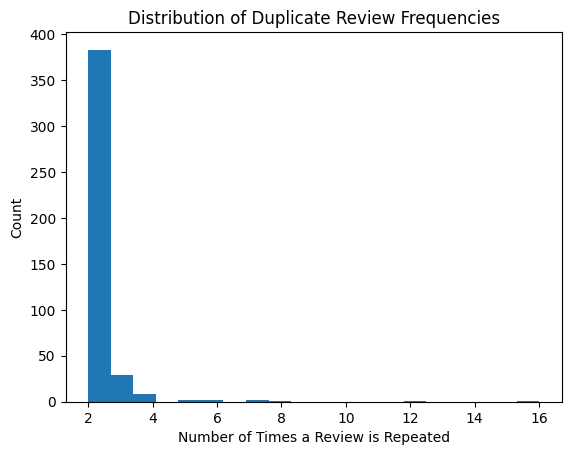

In [14]:
dup_counts = dup_text.groupby("review_text").size()

plt.hist(dup_counts, bins=20)
plt.title("Distribution of Duplicate Review Frequencies")
plt.xlabel("Number of Times a Review is Repeated")
plt.ylabel("Count")
plt.show()

In [15]:
print(df.groupby("review_text")["is_spoiler"].nunique().value_counts())
# Almost all duplicate reviews have consistent labels (573,307), but 78 cases show conflicting labels, minor label noise

is_spoiler
1    573307
2        78
Name: count, dtype: int64


               count         mean          std   min    25%     50%     75%  \
is_spoiler                                                                    
False       422989.0  1308.154425  1021.050440  18.0  682.0   947.0  1575.0   
True        150924.0  1887.676731  1283.848098  50.0  920.0  1459.0  2456.0   

                max  
is_spoiler           
False       14963.0  
True        14302.0  


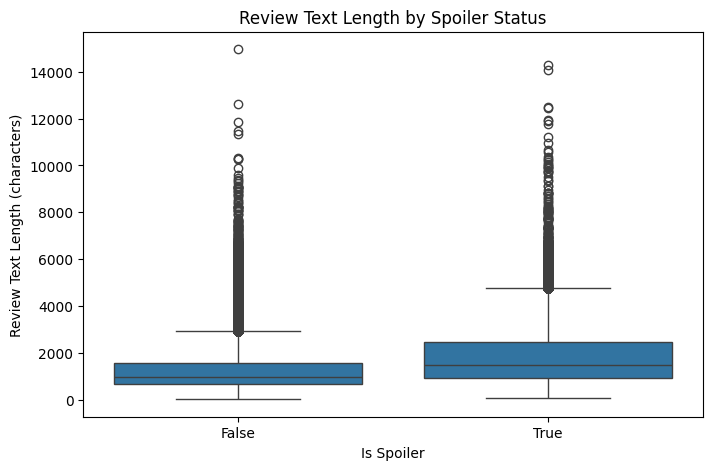

In [16]:
df["length"] = df["review_text"].str.len()
print(df.groupby("is_spoiler")["length"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(x="is_spoiler", y="length", data=df)

plt.title("Review Text Length by Spoiler Status")
plt.xlabel("Is Spoiler")
plt.ylabel("Review Text Length (characters)")
plt.show()
# Spoiler reviews are significantly longer on average (~1888 vs ~1308 chars), suggesting length is could be a useful predictive signal

In [17]:
print(df.groupby("is_spoiler")["rating"].mean())
# Spoiler reviews tend to have lower average ratings (~6.52 vs ~7.11), indicating a potential correlation between sentiment and spoiler likelihood

is_spoiler
False    7.110031
True     6.517665
Name: rating, dtype: float64


count    1572.000000
mean      365.084606
std       283.088117
min         2.000000
25%       165.000000
50%       326.000000
75%       529.000000
max      4845.000000
Name: count, dtype: float64


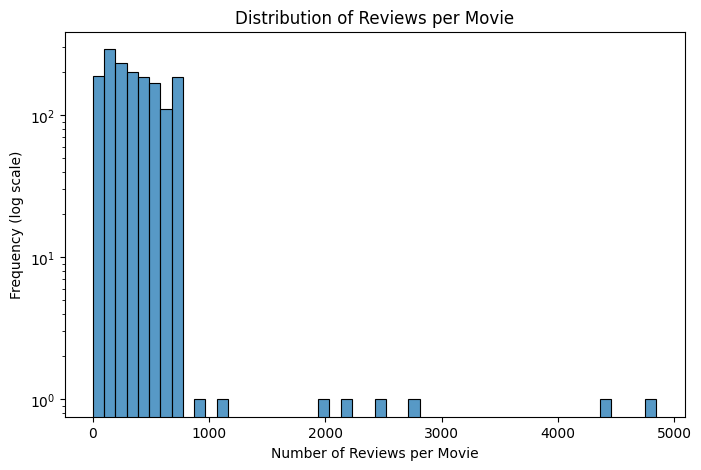

In [18]:
print(df["movie_id"].value_counts().describe())

movie_counts = df["movie_id"].value_counts()

plt.figure(figsize=(8, 5))
sns.histplot(movie_counts, bins=50)

plt.yscale("log")  # critical due to heavy skew
plt.title("Distribution of Reviews per Movie")
plt.xlabel("Number of Reviews per Movie")
plt.ylabel("Frequency (log scale)")
plt.show()
# Review distribution is highly uneven across movies (max ~4845 reviews), indicating potential movie-level bias in the dataset

count    263407.000000
mean          2.178807
std          10.665784
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        1303.000000
Name: count, dtype: float64


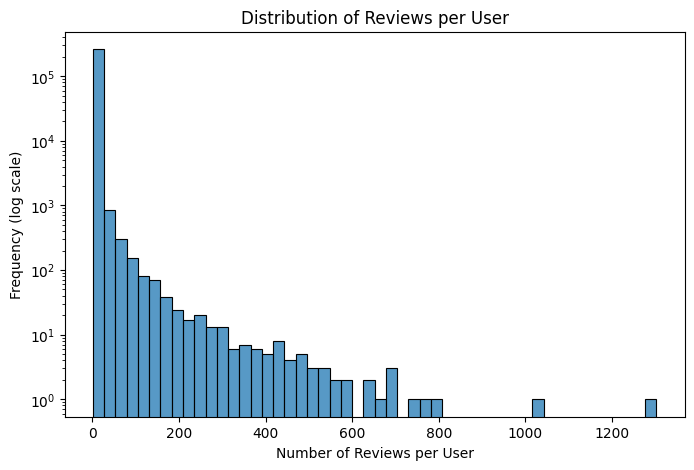

In [19]:
print(df["user_id"].value_counts().describe())

user_counts = df["user_id"].value_counts()

plt.figure(figsize=(8, 5))
sns.histplot(user_counts, bins=50)

plt.yscale("log")
plt.title("Distribution of Reviews per User")
plt.xlabel("Number of Reviews per User")
plt.ylabel("Frequency (log scale)")
plt.show()
# Most users contribute only one review, but a few users are highly active (up to 1303 reviews), introducing potential user-level bias

In [20]:
print((df["review_text"] == df["review_summary"]).sum())
# Review text and summary are almost always different (only 1 identical case), indicating they provide complementary information

1


In [21]:
print(df[df["review_text"].str.len() > 10000].shape)
# Only 25 reviews exceed 10,000 characters, indicating rare but extreme outliers that may impact model efficiency

(25, 8)


In [22]:
# Vectorise review text
vec = CountVectorizer(max_features=1000, stop_words="english", min_df=20)
X = vec.fit_transform(df["review_text"])
feature_names = vec.get_feature_names_out()

# Split matrix by class
spoiler_mask = df["is_spoiler"].values
X_spoiler = X[spoiler_mask]
X_nonspoiler = X[~spoiler_mask]

# Average frequency of each word per review in each class
spoiler_freq = np.asarray(X_spoiler.mean(axis=0)).ravel()
nonspoiler_freq = np.asarray(X_nonspoiler.mean(axis=0)).ravel()

log_ratio = np.log((spoiler_freq + 1e-6) / (nonspoiler_freq + 1e-6))

# Filter out words with extremely low overall frequency
overall_freq = spoiler_freq + nonspoiler_freq
mask = overall_freq > 0.001

filtered_words = feature_names[mask]
filtered_log_ratio = log_ratio[mask]

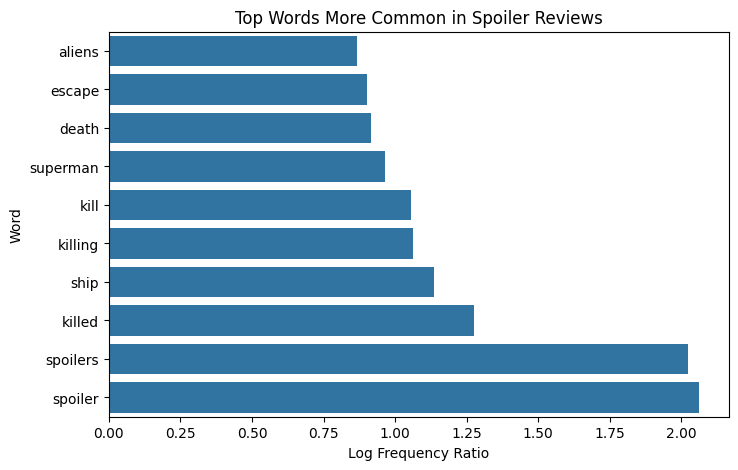

Top spoiler-associated words:
spoiler: 2.063
spoilers: 2.023
killed: 1.278
ship: 1.135
killing: 1.064
kill: 1.057
superman: 0.964
death: 0.915
escape: 0.902
aliens: 0.866


In [23]:
# Top 10 words most associated with spoiler reviews
top_spoiler_idx = np.argsort(filtered_log_ratio)[-10:]
top_spoiler_words = filtered_words[top_spoiler_idx]
top_spoiler_scores = filtered_log_ratio[top_spoiler_idx]

plt.figure(figsize=(8, 5))
sns.barplot(x=top_spoiler_scores, y=top_spoiler_words)
plt.title("Top Words More Common in Spoiler Reviews")
plt.xlabel("Log Frequency Ratio")
plt.ylabel("Word")
plt.show()

print("Top spoiler-associated words:")
for word, score in zip(top_spoiler_words[::-1], top_spoiler_scores[::-1]):
    print(f"{word}: {score:.3f}")
# Many common words associated with spoilers including spoiler(s), kill(ed) and death are more common in spoiler reviews

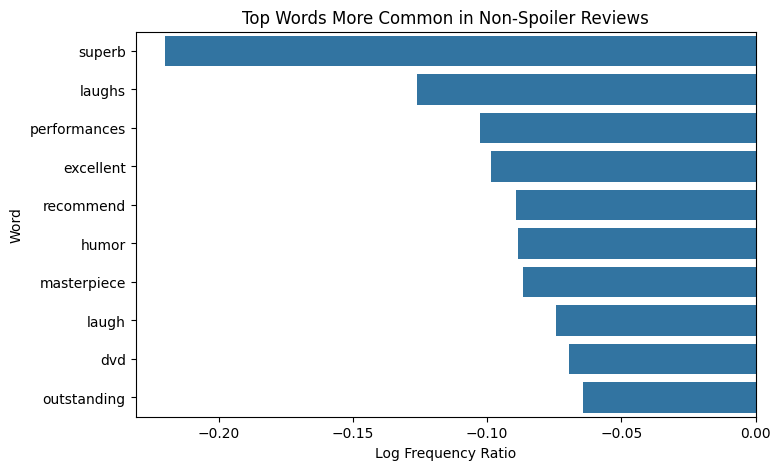


Top non-spoiler-associated words:
superb: -0.220
laughs: -0.126
performances: -0.103
excellent: -0.099
recommend: -0.089
humor: -0.089
masterpiece: -0.087
laugh: -0.074
dvd: -0.070
outstanding: -0.064


In [24]:
# Top 10 words most associated with non-spoiler reviews
top_nonspoiler_idx = np.argsort(filtered_log_ratio)[:10]
top_nonspoiler_words = filtered_words[top_nonspoiler_idx]
top_nonspoiler_scores = filtered_log_ratio[top_nonspoiler_idx]

plt.figure(figsize=(8, 5))
sns.barplot(x=top_nonspoiler_scores, y=top_nonspoiler_words)
plt.title("Top Words More Common in Non-Spoiler Reviews")
plt.xlabel("Log Frequency Ratio")
plt.ylabel("Word")
plt.show()

print("\nTop non-spoiler-associated words:")
for word, score in zip(top_nonspoiler_words, top_nonspoiler_scores):
    print(f"{word}: {score:.3f}")

# The words associated with non-spoilers typically describe qualities of the movie, instead of the movie's plot details.

In [25]:
# Review date stored as object, convert to datetime
df["review_date"] = pd.to_datetime(df["review_date"])

### 1.2 EDA of movies dataset

In [26]:
# Check details of movies dataset
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1572 entries, 0 to 1571
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       1572 non-null   str    
 1   plot_summary   1572 non-null   str    
 2   duration       1572 non-null   str    
 3   genre          1572 non-null   object 
 4   rating         1572 non-null   float64
 5   release_date   1572 non-null   str    
 6   plot_synopsis  1572 non-null   str    
dtypes: float64(1), object(1), str(5)
memory usage: 86.1+ KB


In [27]:
# Check that all entries have unique movie_ids
df_movies["movie_id"].nunique(), len(df_movies)

(1572, 1572)

In [28]:
# Check for missing / unused movies
review_movie_ids = set(df["movie_id"])
movie_ids = set(df_movies["movie_id"])

# Reviews without metadata
missing_movies = review_movie_ids - movie_ids

# Metadata without reviews
unused_movies = movie_ids - review_movie_ids

print("Missing metadata:", len(missing_movies))
print("Unused metadata:", len(unused_movies))

Missing metadata: 2
Unused metadata: 2


In [29]:
# There were 2 missing and 2 unused, looking further into the discrepancy
print("Missing:", missing_movies)
print("Unused:", unused_movies)

# Missing: {'tt0104014', 'tt0114142'}
# Unused: {'tt0114142/', 'tt0104014/'}
# Inconsistency was due to '/'

Missing: {'tt0114142', 'tt0104014'}
Unused: {'tt0104014/', 'tt0114142/'}


In [30]:
# Find all movie_ids ending with '/'
df_movies[df_movies["movie_id"].str.endswith("/")]
# If those 2 movies only: isolated issue, solve later in data cleaning

,movie_id,plot_summary,duration,genre,rating,release_date,plot_synopsis
1570,tt0104014/,"For a while now, beautiful 24-year-old Diana B...",1h 33min,"[Comedy, Drama]",5.3,1992-02-21,
1571,tt0114142/,"The marriage of David Burgess, a senior execut...",1h 32min,"[Drama, Thriller]",4.0,1999-01-29,


count    1572.000000
mean      614.258270
std       240.194629
min        95.000000
25%       423.750000
50%       578.000000
75%       783.500000
max      1077.000000
Name: plot_summary, dtype: float64


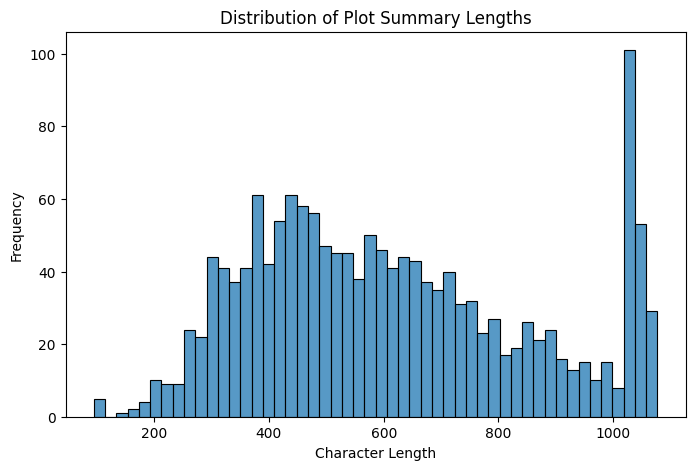

In [31]:
# Checking details of plot summaries
print(df_movies["plot_summary"].str.len().describe())

plt.figure(figsize=(8, 5))
sns.histplot(df_movies["plot_summary"].str.len(), bins=50)

plt.title("Distribution of Plot Summary Lengths")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

count     1572.000000
mean      8214.993639
std       8435.385266
min          0.000000
25%       2898.750000
50%       6192.500000
75%      10871.000000
max      63904.000000
Name: plot_synopsis, dtype: float64


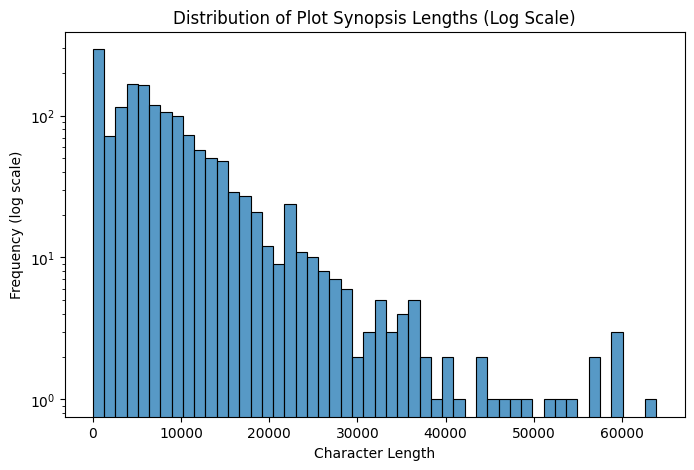

In [32]:
# Checking details of plot synopses
print(df_movies["plot_synopsis"].str.len().describe())
# At least one movie synopsis has length of zero

plt.figure(figsize=(8, 5))
sns.histplot(df_movies["plot_synopsis"].str.len(), bins=50)

plt.yscale("log")
plt.title("Distribution of Plot Synopsis Lengths (Log Scale)")
plt.xlabel("Character Length")
plt.ylabel("Frequency (log scale)")
plt.show()

Number of Empty Synopses:  233


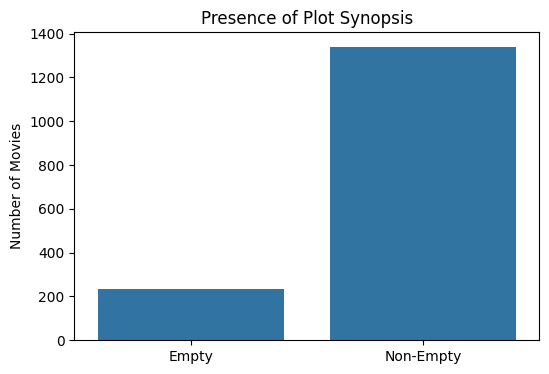

In [33]:
# Check for movie(s) with synopsis of length 0
synopsis_len = df_movies["plot_synopsis"].str.len()

counts = [(synopsis_len == 0).sum(), (synopsis_len > 0).sum()]
print("Number of Empty Synopses: ", (synopsis_len == 0).sum())
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Empty", "Non-Empty"],
    y=counts
)

plt.title("Presence of Plot Synopsis")
plt.ylabel("Number of Movies")
plt.xlabel("")
plt.show()
# 233 movies with an empty plot synopsis

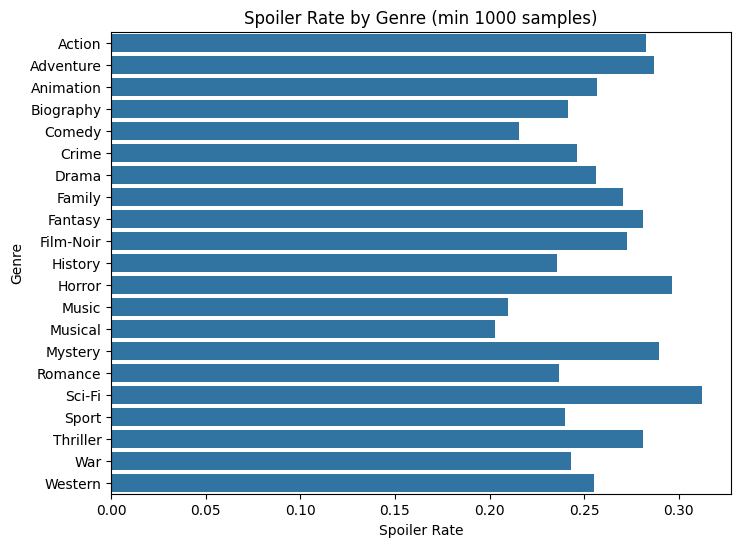

In [34]:
# Check genre details
df_genre = df_movies[["movie_id", "genre"]].explode("genre")
df_merged = df.merge(df_genre, on="movie_id")
genre_spoiler_rate = df_merged.groupby("genre")["is_spoiler"].mean()
genre_counts = df_merged["genre"].value_counts()
mask = genre_counts >= 1000
genre_spoiler_rate = genre_spoiler_rate[mask]

plt.figure(figsize=(8, 6))
sns.barplot(
    x=genre_spoiler_rate.values,
    y=genre_spoiler_rate.index
)

plt.title("Spoiler Rate by Genre (min 1000 samples)")
plt.xlabel("Spoiler Rate")
plt.ylabel("Genre")
plt.show()
# No significant trend or outlier for spoiler rate per genre

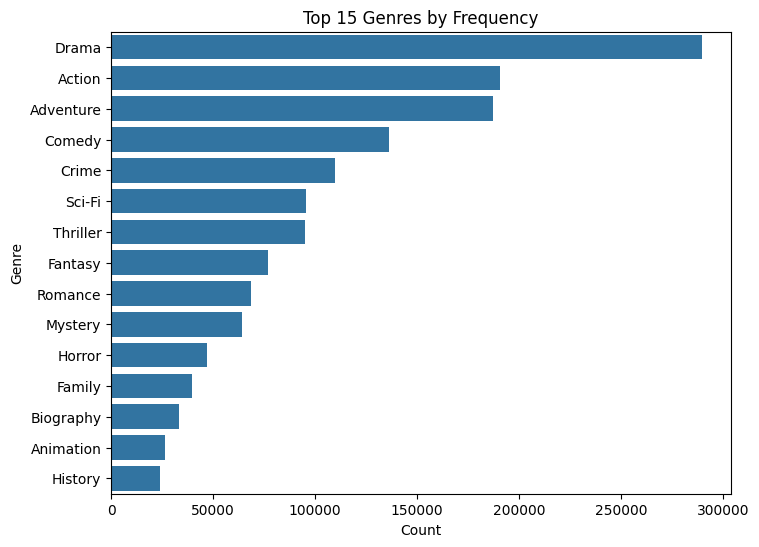

In [35]:
# Check genre distribution
top_genres = genre_counts.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Genres by Frequency")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [36]:
# Checking for genre structure edge cases
print(df_movies[df_movies["genre"].apply(lambda x: not isinstance(x, list))])
print(df_movies[df_movies["genre"].apply(len) == 0])

Empty DataFrame
Columns: [movie_id, plot_summary, duration, genre, rating, release_date, plot_synopsis]
Index: []
Empty DataFrame
Columns: [movie_id, plot_summary, duration, genre, rating, release_date, plot_synopsis]
Index: []


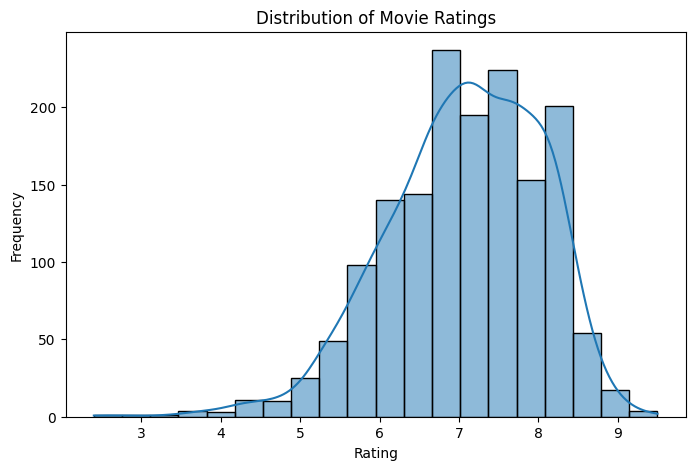

In [37]:
# Checking details of ratings
ratings = df_movies["rating"].astype(float)

plt.figure(figsize=(8, 5))
sns.histplot(ratings, bins=20, kde=True)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Index(['movie_id', 'plot_summary', 'duration', 'genre', 'movie_rating',
       'release_date', 'plot_synopsis'],
      dtype='str')


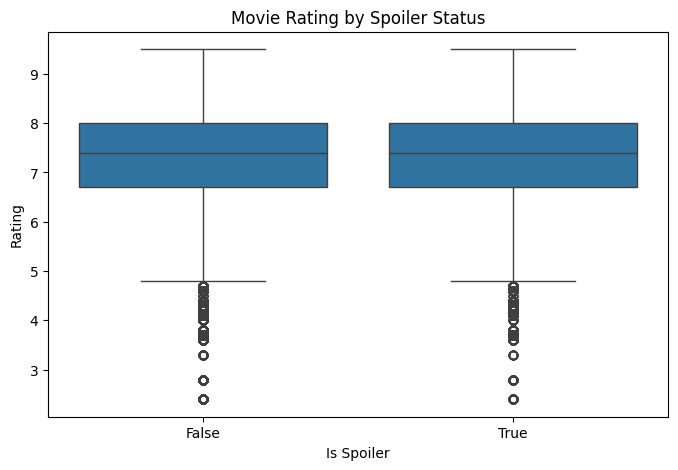

In [38]:
# Change name of movie rating from rating to movie_rating to avoid overlap with review rating
df_movies = df_movies.rename(columns={"rating": "movie_rating"})
# Check whether name change worked
print(df_movies.columns)

# Checking relationship between spoilers and ratings
df_merged = df.merge(df_movies[["movie_id", "movie_rating"]], on="movie_id")

plt.figure(figsize=(8, 5))
sns.boxplot(x="is_spoiler", y="movie_rating", data=df_merged)

plt.title("Movie Rating by Spoiler Status")
plt.xlabel("Is Spoiler")
plt.ylabel("Rating")
plt.show()
# Practically negligible difference in ratings between spoilers and non-spoilers

## 2. Data Cleaning and Preprocessing
This section performs cleaning and preprocessing to build the master dataset used across all downstream modeling steps.

### 2.1 Data Cleaning for reviews

In [39]:
# create master dataset
df_master = df.copy()

In [40]:
# Remove duplicate reviews which have different label assigned to the same text
conflicts = df_master.groupby("review_text")["is_spoiler"].nunique()
conflicts = conflicts[conflicts > 1].index

df_master = df_master[~df_master["review_text"].isin(conflicts)]

# Remove exact duplicate reviews to avoid redundancy and data leakage
df_master = df_master.drop_duplicates(subset=["review_text"])

# Remove extremely short reviews that are likely low-information or noisy
df_master = df_master[df_master["review_text"].str.len() > 25]

# Remove extremely long reviews that may distort feature distributions and increase computational cost
df_master = df_master[df_master["review_text"].str.len() < 10000]

# Add review length as a feature due to strong correlation with spoiler labels
df_master["length"] = df_master["review_text"].str.len()

# Reset index after row removals to keep the cleaned dataset tidy and consistent
df_master = df_master.reset_index(drop=True)

In [41]:
print(df_master.shape)
# Removed 634 reviews
# Additional feature is review length "length"

(573279, 8)


In [42]:
# Re-check class distribution after cleaning to ensure preprocessing did not heavily distort label balance
print(df_master["is_spoiler"].value_counts(normalize=True))
# Original: (73.7% non-spoiler vs 26.3% spoiler), class distribution remained very similar

is_spoiler
False    0.737009
True     0.262991
Name: proportion, dtype: float64


In [43]:
# Verify that exact duplicate reviews have been fully removed
print(df_master.duplicated(subset=["review_text"]).sum())
# No duplicates left

0


In [44]:
# Verify that no identical review text remains with conflicting spoiler labels
print(df_master.groupby("review_text")["is_spoiler"].nunique().value_counts())
# All review_texts have only 1 label

is_spoiler
1    573279
Name: count, dtype: int64


In [45]:
# Check that there are no invalid movie_ids
invalid_ids_reviews = df_master[~df_master["movie_id"].str.match(r"^tt\d+$", na=False)]
print(len(invalid_ids_reviews))

0


In [46]:
# Review date stored as object, convert to datetime
df_master["review_date"] = pd.to_datetime(df_master["review_date"])

In [47]:
# Basic data cleaning function
def basic_clean(text):
    text = str(text) # Forces text to be a String
    text = html.unescape(text) # Converts HTML to normal text
    text = unicodedata.normalize("NFKC", text) # Normalizes unicode into a consistent canonical form
    text = re.sub(r"<[^>]+>", " ", text) # Removes HTML tags 
    text = text.lower() # Converts all text to lowercase
    text = re.sub(r"\s+", " ", text) # Collapses all whitespace into a single space
    text = text.strip() # Removes whitespace in front and behind of text
    return text

In [48]:
# Clean "clean_text" in master dataframe
df_master["clean_text"] = df_master["review_text"].apply(basic_clean)

In [49]:
# Compare clean_text to review_text
pd.set_option("display.max_colwidth", None)
df_master[["review_text", "clean_text"]].sample(3, random_state=42)

,review_text,clean_text
450069,"I'm sorry. I wanted to like it so much.I've been a fan of the show for years. I've watched every episode 10 times. I was so incredibly excited when I heard a movie was being made. Unfortunately, it wasn't the movie I was hoping to see.It's great to hear Carrie's voice again, talking about her and her friends little dramas. But even SATC got 'carried away' with that Hollywood cheesiness. Where the show was spicy and provocative, the movie was too long and moralizing. Though some of the dialogs where pretty good, a lot of others weren't. The half of the time I felt like I was watching 4 totally different people than I saw and the show 4 years ago. Also, the story was pitiful (Carrie marries Big - oh no, she doesn't! - wait, she does!), they just tried to squeeze every possible scenario in 144 minutes (alot of breaking up and getting back together). And even my two favorite gay men had like two lines in the whole movie! The only great thing in the movie was the wardrobe. Compliment to Patricia Field, she has done it again! (Though the designer logos were shooting of the screen). But when the critics said this movie was made 'just for the fans', they were wrong. This movie was made for people who have no clue of what Sex And The City is, and just want a fun girls night out. The fans however, will be disappointed.I'm sorry. I wanted to like it so much (I rate it '10' just on my personal account, so it wouldn't be suck on a 3,5, cause it doesn't deserve that either), but Sex and the City is just a mess of very very good fashion, and bad fart jokes. But I will buy it on DVD. Just to finish my collection.","i'm sorry. i wanted to like it so much.i've been a fan of the show for years. i've watched every episode 10 times. i was so incredibly excited when i heard a movie was being made. unfortunately, it wasn't the movie i was hoping to see.it's great to hear carrie's voice again, talking about her and her friends little dramas. but even satc got 'carried away' with that hollywood cheesiness. where the show was spicy and provocative, the movie was too long and moralizing. though some of the dialogs where pretty good, a lot of others weren't. the half of the time i felt like i was watching 4 totally different people than i saw and the show 4 years ago. also, the story was pitiful (carrie marries big - oh no, she doesn't! - wait, she does!), they just tried to squeeze every possible scenario in 144 minutes (alot of breaking up and getting back together). and even my two favorite gay men had like two lines in the whole movie! the only great thing in the movie was the wardrobe. compliment to patricia field, she has done it again! (though the designer logos were shooting of the screen). but when the critics said this movie was made 'just for the fans', they were wrong. this movie was made for people who have no clue of what sex and the city is, and just want a fun girls night out. the fans however, will be disappointed.i'm sorry. i wanted to like it so much (i rate it '10' just on my personal account, so it wouldn't be suck on a 3,5, cause it doesn't deserve that either), but sex and the city is just a mess of very very good fashion, and bad fart jokes. but i will buy it on dvd. just to finish my collection."
495181,"20 years after this movie came out and it can still surprise you. I first watched about two or three years ago and I very much liked it. What really surprised me is that even the bad guy, Dr. Varnick, made me laugh. This movie is funny and appropriate for children. It does contain some things that parents might consider inappropriate for children who are very little or who are sensitive. Some material might be frightening, but overall it's a nice movie. It will make you laugh, especially the dog-nappers.The Saint Bernard became the center of attention of the whole family.At the beginning I thought that the family wouldn't accept the dog, but I kept my hopes up. I would recommend this movie to anyon

### 2.2 Data Cleaning for movies

In [50]:
# create master dataset for movies
df_master_movies = df_movies.copy()

In [51]:
# Show the wrong ids identified earlier
invalid_ids = df_movies[~df_movies["movie_id"].str.match(r"^tt\d+$", na=False)]
invalid_ids["movie_id"]

1570    tt0104014/
1571    tt0114142/
Name: movie_id, dtype: str

In [52]:
# Fix the movie id error identified earlier
df_master_movies["movie_id"] = df_master_movies["movie_id"].str.rstrip("/")

# Recheck
review_movie_ids = set(df["movie_id"])
movie_ids = set(df_master_movies["movie_id"])

# reviews without metadata
missing_movies = review_movie_ids - movie_ids

# metadata without reviews
unused_movies = movie_ids - review_movie_ids

print("Missing metadata:", len(missing_movies))
print("Unused metadata:", len(unused_movies))
# No more missing and unused metadata

Missing metadata: 0
Unused metadata: 0


In [53]:
# Change name of movie rating from rating to movie_rating to avoid overlap with review rating
df_master_movies = df_master_movies.rename(columns={"rating": "movie_rating"})
# Check whether name change worked
print(df_master_movies.columns)

Index(['movie_id', 'plot_summary', 'duration', 'genre', 'movie_rating',
       'release_date', 'plot_synopsis'],
      dtype='str')


In [54]:
# Changing release date from string to datetime
df_master_movies["release_date"] = pd.to_datetime(df_movies["release_date"], errors="coerce")

df_master_movies["release_year"] = df_master_movies["release_date"].dt.year

df_master_movies["release_year"].describe()
# Count of release years is 10 less than the number of movies, 10 movies do not have a release date after conversion

count    1562.000000
mean     2001.149808
std        13.575729
min      1921.000000
25%      1995.000000
50%      2003.000000
75%      2010.000000
max      2018.000000
Name: release_year, dtype: float64

In [55]:
# Checking release date for the 10 movies
df_master_movies[df_master_movies["release_year"].isna()][["movie_id", "release_date"]]

,movie_id,release_date
161,tt0060107,NaT
276,tt0099566,NaT
287,tt0104545,NaT
332,tt0052311,NaT
554,tt0050825,NaT
796,tt0100263,NaT
1208,tt0015864,NaT
1216,tt0050083,NaT
1472,tt0036868,NaT
1497,tt0047396,NaT


In [56]:
# Checking what the original release year entries were for these movies
failed_ids = df_master_movies[df_master_movies["release_year"].isna()]["movie_id"]

df_movies[df_movies["movie_id"].isin(failed_ids)][["movie_id", "release_date"]]

,movie_id,release_date
161,tt0060107,1973
276,tt0099566,1991-03
287,tt0104545,1994-02
332,tt0052311,1958-02
554,tt0050825,1957-11
796,tt0100263,1991-04
1208,tt0015864,1925
1216,tt0050083,1957-04
1472,tt0036868,1947
1497,tt0047396,1954-09


In [57]:
# Fix the empty release years
year_fix = {
    "tt0060107": 1973,
    "tt0099566": 1991,
    "tt0104545": 1994,
    "tt0052311": 1958,
    "tt0050825": 1957,
    "tt0100263": 1991,
    "tt0015864": 1925,
    "tt0050083": 1957,
    "tt0036868": 1947,
    "tt0047396": 1954,
}

df_master_movies["release_year"] = df_master_movies.apply(
    lambda row: year_fix.get(row["movie_id"], row["release_year"]),
    axis=1
)

# Check whether release years are fixed
print(df_master_movies[df_master_movies["release_year"].isna()][["movie_id", "release_date"]])
print(df_master_movies[df_master_movies["movie_id"].isin(failed_ids)][["movie_id", "release_year"]])

Empty DataFrame
Columns: [movie_id, release_date]
Index: []
       movie_id  release_year
161   tt0060107        1973.0
276   tt0099566        1991.0
287   tt0104545        1994.0
332   tt0052311        1958.0
554   tt0050825        1957.0
796   tt0100263        1991.0
1208  tt0015864        1925.0
1216  tt0050083        1957.0
1472  tt0036868        1947.0
1497  tt0047396        1954.0


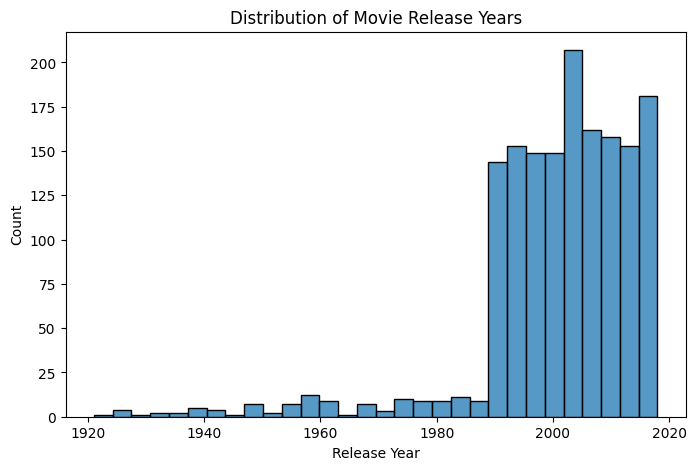

In [58]:
# Distribution of movie years
plt.figure(figsize=(8, 5))
sns.histplot(df_master_movies["release_year"], bins=30)

plt.title("Distribution of Movie Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

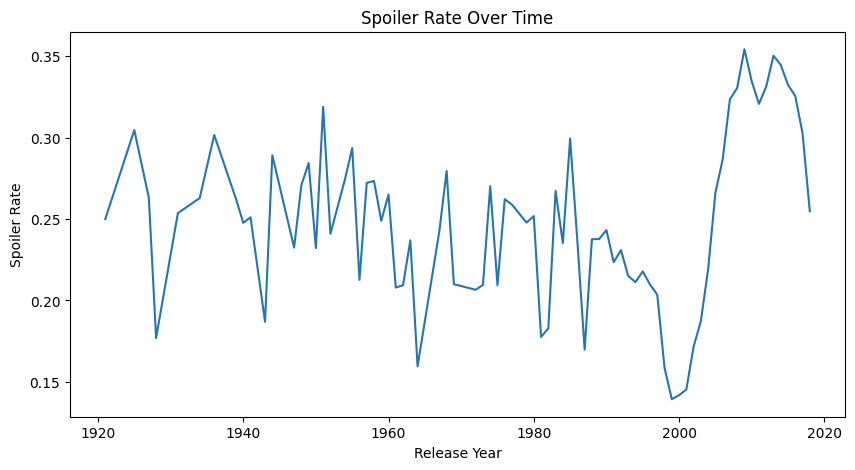

In [59]:
# Spoiler rates over the years
df_merged = df.merge(df_master_movies[["movie_id", "release_year"]], on="movie_id")
year_spoiler = df_merged.groupby("release_year")["is_spoiler"].mean()

plt.figure(figsize=(10, 5))
year_spoiler.plot()

plt.title("Spoiler Rate Over Time")
plt.xlabel("Release Year")
plt.ylabel("Spoiler Rate")
plt.show()
# Since most movies in the dataset are very recent, the estimates for spoiler rate in the earlier time periods are very unstable

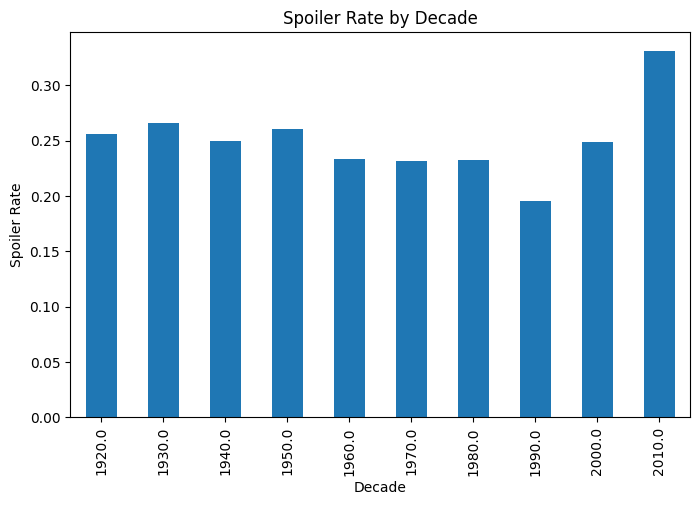

In [60]:
# Spoiler rate over decades
df_merged["decade"] = (df_merged["release_year"] // 10) * 10

decade_spoiler = df_merged.groupby("decade")["is_spoiler"].mean()

plt.figure(figsize=(8, 5))
decade_spoiler.plot(kind="bar")

plt.title("Spoiler Rate by Decade")
plt.xlabel("Decade")
plt.ylabel("Spoiler Rate")
plt.show()
# After combining into decades, spoiler rates show some variation across time,
# though this may reflect dataset and behavioral biases rather than intrinsic temporal effects

In [61]:
# Changing movie duration from string to number
df_master_movies["duration_minutes"] = (
    df_master_movies["duration"]
    .str.extract(r'(?:(\d+)h)?\s*(?:(\d+)min)?')
    .astype(float)
    .fillna(0)
    .assign(total=lambda x: x[0]*60 + x[1])["total"]
)

In [62]:
# Checking details of movie duration
print(df_master_movies[["duration", "duration_minutes"]].head())
print(df_master_movies["duration_minutes"].describe())

   duration  duration_minutes
0  1h 57min             117.0
1  1h 45min             105.0
2  1h 37min              97.0
3   2h 6min             126.0
4  1h 43min             103.0
count    1572.000000
mean      115.269084
std        24.544471
min        42.000000
25%       100.000000
50%       113.000000
75%       128.000000
max       321.000000
Name: duration_minutes, dtype: float64


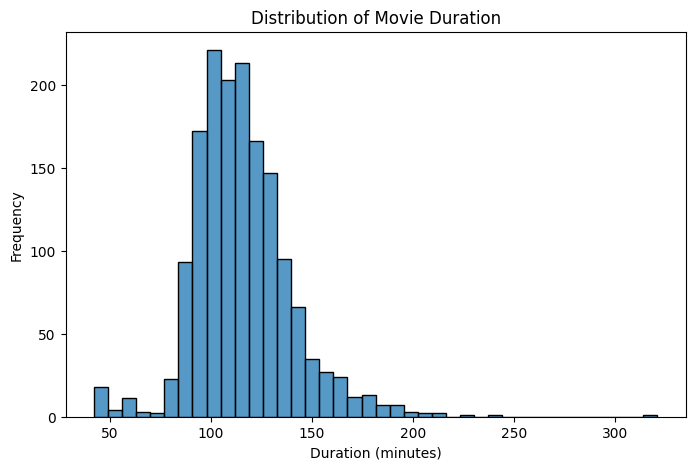

In [63]:
# Distribution of movie duration
plt.figure(figsize=(8, 5))
sns.histplot(df_master_movies["duration_minutes"], bins=40)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

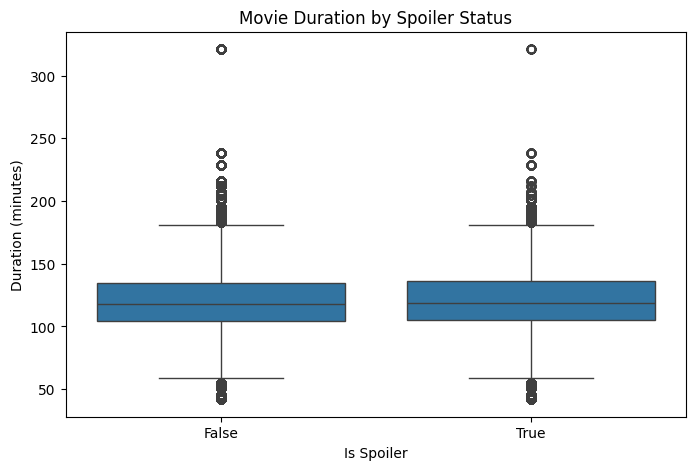

In [64]:
# Checking relationship between duration and spoiler status
df_merged = df.merge(
    df_master_movies[["movie_id", "duration_minutes"]],
    on="movie_id"
)

plt.figure(figsize=(8, 5))
sns.boxplot(x="is_spoiler", y="duration_minutes", data=df_merged)

plt.title("Movie Duration by Spoiler Status")
plt.xlabel("Is Spoiler")
plt.ylabel("Duration (minutes)")
plt.show()
# No observable trend or relationship

In [65]:
# Drop old string duration column
df_master_movies = df_master_movies.drop(columns=["duration"])

In [66]:
# Basic data cleaning function for movie summary and synopsis
def basic_clean_movie(text):
    if pd.isna(text):
        return ""
    text = str(text) # Forces text to be a String
    text = html.unescape(text) # Converts HTML to normal text
    text = unicodedata.normalize("NFKC", text) # Normalizes unicode into a consistent canonical form
    text = re.sub(r"<[^>]+>", " ", text) # Removes HTML tags 
    text = text.lower() # Converts all text to lowercase
    text = re.sub(r"\s+", " ", text) # Collapses all whitespace into a single space
    text = text.strip() # Removes whitespace in front and behind of text
    return text

In [67]:
# add cleaned summary and synopsis to master movie dataframe
df_master_movies["plot_summary_clean"] = df_master_movies["plot_summary"].apply(basic_clean_movie)
df_master_movies["plot_synopsis_clean"] = df_master_movies["plot_synopsis"].apply(basic_clean_movie)

This subsection examines whether spoiler labels are correlated with movie-level data.

In [68]:
# Create joined dataset
df_joined = df_master.merge(df_master_movies, on="movie_id", how="left")

In [69]:
# Compare means by class
df_joined.groupby("is_spoiler")[[
    "release_year",
    "duration_minutes",
    "movie_rating"
]].mean()

,release_year,duration_minutes,movie_rating
is_spoiler,,,
False,2002.459755,120.930968,7.297736
True,2004.661551,121.116438,7.279640


In [70]:
# Check correlation between spoiler rate and each movie-level detail
movie_level = df_joined.groupby("movie_id").agg({
    "is_spoiler": "mean",   # spoiler rate per movie
    "release_year": "first",
    "duration_minutes": "first",
    "movie_rating": "first"
})
movie_level.corr()
# Weak correlation between spoiler status and movie-level details except for release year and spoiler status
# Release year and spoiler status have positive correlation of approximately 0.2778
# Correlation between release year and spoiler status is likely due to the heavily-skewed distribution of release years, not a causal relationship

,is_spoiler,release_year,duration_minutes,movie_rating
is_spoiler,1.000000,0.277722,0.036884,0.026231
release_year,0.277722,1.000000,-0.057506,-0.199517
duration_minutes,0.036884,-0.057506,1.000000,0.259208
movie_rating,0.026231,-0.199517,0.259208,1.000000


In [71]:
movie_level.groupby(pd.cut(movie_level["release_year"], bins=10))["is_spoiler"].mean()
# the correlation observed between release year and spoiler boolean is likely due to general
# increased review counts for modern movies, not very useful for prediction of spoilers

release_year
(1920.903, 1930.7]    0.260148
(1930.7, 1940.4]      0.263170
(1940.4, 1950.1]      0.247975
(1950.1, 1959.8]      0.264974
(1959.8, 1969.5]      0.238448
(1969.5, 1979.2]      0.235035
(1979.2, 1988.9]      0.230964
(1988.9, 1998.6]      0.208278
(1998.6, 2008.3]      0.216609
(2008.3, 2018.0]      0.318832
Name: is_spoiler, dtype: float64

In [72]:
# Code for getting the json of df_master_movies
#df_master_movies.to_json("movie_details_cleaned.json", orient="records", force_ascii=False)

## 3. Data Splitting
Split data by movie so the model does not learn movie-specific context as a shortcut for spoiler detection.

The current workflow uses a group-based train/test split by `movie_id`, followed by a shared validation set and two artifact-specific training subsets for downstream feature generation and model tuning.

Approximate split proportion for the initial grouped split:  
Training: 0.80  
Testing: 0.20

In [73]:
# Function for splitting data into training and testing sets
def group_data_split(df, group_col="movie_id", test_size=0.2, random_state=42):
    """
    Split a dataframe into train and test sets using group-based splitting.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    group_col : str, default="movie_id"
        Column used to define groups that must not be split across train and test.
    test_size : float, default=0.2
        Proportion of groups to place in the test set.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    df_train : pandas.DataFrame
        Training subset.
    df_test : pandas.DataFrame
        Test subset.
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    return df_train, df_test

In [74]:
# Splitting data into training set and testing set (grouped by movie_id)
df_train, df_test = group_data_split(
    df_master, 
    group_col="movie_id", 
    test_size=0.2, 
    random_state=42
)

### 3.1 Validation Split for Hyperparameter Tuning
Create `df_val` as 15% of `df_train`, with its class balance aligned to the spoiler/non-spoiler ratio in `df_test`, and reserve the remaining 85% for artifact-specific training subset construction.

In [75]:
# Match df_val class ratio to df_test class ratio
VAL_SIZE = 0.15
VAL_SEED = 42

test_spoiler_ratio = df_test["is_spoiler"].mean()
n_val = int(round(len(df_train) * VAL_SIZE))
target_val_spoiler = int(round(n_val * test_spoiler_ratio))
target_val_nonspoiler = n_val - target_val_spoiler

train_spoiler_pool = df_train[df_train["is_spoiler"] == True]
train_nonspoiler_pool = df_train[df_train["is_spoiler"] == False]

if target_val_spoiler > len(train_spoiler_pool):
    raise ValueError(
        f"Target validation spoiler count ({target_val_spoiler}) exceeds available spoilers in df_train ({len(train_spoiler_pool)})."
    )
if target_val_nonspoiler > len(train_nonspoiler_pool):
    raise ValueError(
        f"Target validation non-spoiler count ({target_val_nonspoiler}) exceeds available non-spoilers in df_train ({len(train_nonspoiler_pool)})."
    )

val_spoilers = train_spoiler_pool.sample(n=target_val_spoiler, random_state=VAL_SEED, replace=False)
val_nonspoilers = train_nonspoiler_pool.sample(n=target_val_nonspoiler, random_state=VAL_SEED, replace=False)

df_val = pd.concat([val_spoilers, val_nonspoilers], axis=0)
df_val = df_val.sample(frac=1, random_state=VAL_SEED).reset_index(drop=True)

val_indices = set(val_spoilers.index).union(set(val_nonspoilers.index))
df_train_remaining = df_train.loc[~df_train.index.isin(val_indices)].reset_index(drop=True)

print("df_train shape:", df_train.shape)
print("df_val shape:", df_val.shape)
print("df_train_remaining shape:", df_train_remaining.shape)
print("Spoiler rate in df_test:", round(df_test["is_spoiler"].mean(), 4))
print("Spoiler rate in df_val:", round(df_val["is_spoiler"].mean(), 4))


df_train shape: (463816, 9)
df_val shape: (69572, 9)
df_train_remaining shape: (394244, 9)
Spoiler rate in df_test: 0.2582
Spoiler rate in df_val: 0.2582


### 3.2 Undersampled Datasets

Using the remaining 85% of the original training split after creating `df_val`, we construct two undersampled training subsets with a target class ratio of 40% spoiler to 60% non-spoiler.

All spoiler samples in the remaining training pool are retained in both subsets. The two artifacts differ only in the non-spoiler class, where each artifact uses a different random sample of non-spoiler reviews.

We then create `df_fulltrain_1` and `df_fulltrain_2` by adding the shared validation set `df_val` back to each artifact-specific subset for final retraining after hyperparameter selection.

In [76]:
TARGET_SPOILER_RATIO = 0.4
TARGET_NONSPOILER_RATIO = 0.6

df_train_spoiler = df_train_remaining[df_train_remaining["is_spoiler"] == True]
df_train_nonspoiler = df_train_remaining[df_train_remaining["is_spoiler"] == False]

n_spoiler = len(df_train_spoiler)
target_nonspoiler = int(round(n_spoiler * (TARGET_NONSPOILER_RATIO / TARGET_SPOILER_RATIO)))

if target_nonspoiler > len(df_train_nonspoiler):
    raise ValueError(
        f"Target non-spoiler sample ({target_nonspoiler}) exceeds available non-spoilers ({len(df_train_nonspoiler)})."
    )

def build_train_subset(nonspoiler_seed: int):
    sampled_nonspoiler = df_train_nonspoiler.sample(
        n=target_nonspoiler,
        random_state=nonspoiler_seed,
        replace=False,
    )
    subset_df = pd.concat([df_train_spoiler, sampled_nonspoiler], axis=0)
    subset_df = subset_df.sample(frac=1, random_state=nonspoiler_seed).reset_index(drop=True)
    return subset_df

# Same spoiler pool, different non-spoiler random samples.
df_train_1 = build_train_subset(nonspoiler_seed=42)
df_train_2 = build_train_subset(nonspoiler_seed=43)

# Full-train variants for final retraining after hyperparameter tuning (subset + validation).
df_fulltrain_1 = pd.concat([df_train_1, df_val], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
df_fulltrain_2 = pd.concat([df_train_2, df_val], axis=0).sample(frac=1, random_state=43).reset_index(drop=True)

spoilers_1 = set(df_train_1.loc[df_train_1["is_spoiler"], "review_text"])
spoilers_2 = set(df_train_2.loc[df_train_2["is_spoiler"], "review_text"])
nonspoilers_1 = set(df_train_1.loc[~df_train_1["is_spoiler"], "review_text"])
nonspoilers_2 = set(df_train_2.loc[~df_train_2["is_spoiler"], "review_text"])
assert spoilers_1 == spoilers_2, "Spoiler sets differ between df_train_1 and df_train_2."

print("df_train_1 shape:", df_train_1.shape)
print("df_train_2 shape:", df_train_2.shape)
print("df_fulltrain_1 shape:", df_fulltrain_1.shape)
print("df_fulltrain_2 shape:", df_fulltrain_2.shape)
print("Spoilers in df_train_1:", int(df_train_1["is_spoiler"].sum()))
print("Spoilers in df_train_2:", int(df_train_2["is_spoiler"].sum()))
print("Non-spoilers in df_train_1:", int((~df_train_1["is_spoiler"]).sum()))
print("Non-spoilers in df_train_2:", int((~df_train_2["is_spoiler"]).sum()))
print("Class proportions df_train_1:")
print(df_train_1["is_spoiler"].value_counts(normalize=True).sort_index())
print("Class proportions df_train_2:")
print(df_train_2["is_spoiler"].value_counts(normalize=True).sort_index())
print("Class proportions df_fulltrain_1:")
print(df_fulltrain_1["is_spoiler"].value_counts(normalize=True).sort_index())
print("Class proportions df_fulltrain_2:")
print(df_fulltrain_2["is_spoiler"].value_counts(normalize=True).sort_index())
print("Spoiler sets identical:", spoilers_1 == spoilers_2)
print("Non-spoiler sets identical:", nonspoilers_1 == nonspoilers_2)

df_train_1 shape: (261360, 9)
df_train_2 shape: (261360, 9)
df_fulltrain_1 shape: (330932, 9)
df_fulltrain_2 shape: (330932, 9)
Spoilers in df_train_1: 104544
Spoilers in df_train_2: 104544
Non-spoilers in df_train_1: 156816
Non-spoilers in df_train_2: 156816
Class proportions df_train_1:
is_spoiler
False    0.6
True     0.4
Name: proportion, dtype: float64
Class proportions df_train_2:
is_spoiler
False    0.6
True     0.4
Name: proportion, dtype: float64
Class proportions df_fulltrain_1:
is_spoiler
False    0.629815
True     0.370185
Name: proportion, dtype: float64
Class proportions df_fulltrain_2:
is_spoiler
False    0.629815
True     0.370185
Name: proportion, dtype: float64
Spoiler sets identical: True
Non-spoiler sets identical: False


In [77]:
# # Create Stratified Group K-Fold splits on the training set
# N_SPLITS = 5
# CV_SEED = 42
# cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# cv_splits = list(
#     cv.split(
#         df_train["clean_text"],
#         df_train["is_spoiler"],
#         groups=df_train["movie_id"],
#     )
# )
# print("Number of CV folds:", len(cv_splits))

In [78]:
# # Sanity checks for data splitting
# # No leakage between train and test
# assert set(df_train["movie_id"]).isdisjoint(df_test["movie_id"])

# # Check approximate sizes
# print("Train size:", len(df_train))
# print("Test size:", len(df_test))
# print("Train proportion:", len(df_train) / len(df_master))
# print("Test proportion:", len(df_test) / len(df_master))

# # Check class balance
# print("\nSpoiler rate")
# print("Full  :", df_master["is_spoiler"].mean())
# print("Train :", df_train["is_spoiler"].mean())
# print("Test  :", df_test["is_spoiler"].mean())

# # Check number of unique movies
# print("\nUnique movies")
# print("Full  :", df_master["movie_id"].nunique())
# print("Train :", df_train["movie_id"].nunique())
# print("Test  :", df_test["movie_id"].nunique())

# # Check fold sizes and balance
# for i, (train_idx, val_idx) in enumerate(cv_splits, 1):
#     y_tr = df_train.iloc[train_idx]["is_spoiler"]
#     y_val = df_train.iloc[val_idx]["is_spoiler"]
#     print(f"Fold {i}: train={len(train_idx)}, val={len(val_idx)}, train_spoiler={y_tr.mean():.3f}, val_spoiler={y_val.mean():.3f}")

In [79]:
# # Checking movie level features across folds
# for i, (_, val_idx) in enumerate(cv_splits):
#     fold_movies = df_train.iloc[val_idx]["movie_id"].unique()
#     fold_df = df_master_movies[df_master_movies["movie_id"].isin(fold_movies)]
#     genre_counts = fold_df["genre"].explode().value_counts(normalize=True)
    
#     print(f"\nFold {i}")
#     print("Movies:", len(fold_movies))
#     print("Avg movie rating:", fold_df["movie_rating"].mean())
#     print("Avg duration:", fold_df["duration_minutes"].mean())
#     print("Avg year:", fold_df["release_year"].mean())
#     print("Top genres:", genre_counts.head())

# # Distribution of movie data is relatively even

## 4. Feature Engineering

This section builds feature sets for each artifact stream using the undersampled training subset for tuning, the full validation set, the full test set, and the corresponding `fulltrain` split for final retraining.
Artifacts are saved separately for `artifacts_1` and `artifacts_2` for both the TF-IDF and TF-IDF + lemmatization pipelines. These artifact streams are derived from the movie-level grouped splits created in Section 3.

In [80]:
required_splits = ["df_train_1", "df_train_2", "df_fulltrain_1", "df_fulltrain_2", "df_val"]
missing_splits = [name for name in required_splits if name not in globals()]
if missing_splits:
    raise ValueError(f"Please run Section 3 cells first. Missing: {missing_splits}")

ARTIFACT_SPLIT_MAP = {
    "artifacts_1": {
        "train": df_train_1.copy(),
        "fulltrain": df_fulltrain_1.copy(),
    },
    "artifacts_2": {
        "train": df_train_2.copy(),
        "fulltrain": df_fulltrain_2.copy(),
    },
}
VAL_FE_DF = df_val.copy()
TEST_FE_DF = df_test.copy()

for artifact_name, split_map in ARTIFACT_SPLIT_MAP.items():
    artifact_dir = Path(artifact_name)
    artifact_dir.mkdir(parents=True, exist_ok=True)
    print(
        f"{artifact_name}: "
        f"train={len(split_map['train'])}, "
        f"fulltrain={len(split_map['fulltrain'])}, "
        f"val={len(VAL_FE_DF)}, test={len(TEST_FE_DF)}"
    )

print("Shared full validation set size:", len(VAL_FE_DF))
print("Shared full test set size:", len(TEST_FE_DF))

artifacts_1: train=261360, fulltrain=330932, val=69572, test=109463
artifacts_2: train=261360, fulltrain=330932, val=69572, test=109463
Shared full validation set size: 69572
Shared full test set size: 109463


In [81]:
TEXT_COL = "clean_text"
LABEL_COL = "is_spoiler"

### 4.1 TF-IDF (No Lemmatization)

In [ ]:
# TF-IDF (no lemma) for train/val/test and fulltrain/test across artifacts_1 and artifacts_2
from sklearn.feature_extraction.text import TfidfVectorizer

TEXT_COL = "clean_text"
LABEL_COL = "is_spoiler"

def clean_corpus(texts):
    return [str(t) for t in texts]

def make_vectorizer():
    return TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english",
        dtype=np.float32,
    )

def build_tfidf_artifacts(df_train_in, df_fulltrain_in, df_val_in, df_test_in, artifact_dir_name):
    artifact_dir = Path(artifact_dir_name)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    # Persist labels for all relevant splits.
    np.save(artifact_dir / "labels_train.npy", df_train_in[LABEL_COL].to_numpy(dtype=np.int64))
    np.save(artifact_dir / "labels_fulltrain.npy", df_fulltrain_in[LABEL_COL].to_numpy(dtype=np.int64))
    np.save(artifact_dir / "labels_val.npy", df_val_in[LABEL_COL].to_numpy(dtype=np.int64))
    np.save(artifact_dir / "labels_test.npy", df_test_in[LABEL_COL].to_numpy(dtype=np.int64))

    # Tuning features: fit on undersampled train, transform val/test.
    tfidf_vec = make_vectorizer()
    X_train = tfidf_vec.fit_transform(clean_corpus(df_train_in[TEXT_COL]))
    X_val = tfidf_vec.transform(clean_corpus(df_val_in[TEXT_COL]))
    X_test = tfidf_vec.transform(clean_corpus(df_test_in[TEXT_COL]))

    joblib.dump(tfidf_vec, artifact_dir / "tfidf_vectorizer.joblib")
    sparse.save_npz(artifact_dir / "X_tfidf_train.npz", X_train)
    sparse.save_npz(artifact_dir / "X_tfidf_val.npz", X_val)
    sparse.save_npz(artifact_dir / "X_tfidf_test.npz", X_test)

    # Final-retraining features: fit on fulltrain (train + val), transform test.
    tfidf_vec_fulltrain = make_vectorizer()
    X_fulltrain = tfidf_vec_fulltrain.fit_transform(clean_corpus(df_fulltrain_in[TEXT_COL]))
    X_test_fulltrain = tfidf_vec_fulltrain.transform(clean_corpus(df_test_in[TEXT_COL]))

    joblib.dump(tfidf_vec_fulltrain, artifact_dir / "tfidf_vectorizer_fulltrain.joblib")
    sparse.save_npz(artifact_dir / "X_tfidf_fulltrain.npz", X_fulltrain)
    sparse.save_npz(artifact_dir / "X_tfidf_test_fulltrain.npz", X_test_fulltrain)

    print(
        f"Saved TF-IDF artifacts to {artifact_dir} | "
        f"train={X_train.shape}, val={X_val.shape}, test={X_test.shape}, "
        f"fulltrain={X_fulltrain.shape}, test_fulltrain={X_test_fulltrain.shape}"
    )

for artifact_name, split_map in ARTIFACT_SPLIT_MAP.items():
    build_tfidf_artifacts(
        split_map["train"],
        split_map["fulltrain"],
        VAL_FE_DF,
        TEST_FE_DF,
        artifact_name,
    )

### 4.2 TF-IDF + Lemmatization

In [ ]:
# TF-IDF + lemma for train/val/test and fulltrain/test across artifacts_1 and artifacts_2
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer

TEXT_COL = "clean_text"
LABEL_COL = "is_spoiler"
_TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def clean_corpus(texts):
    return [str(t) for t in texts]

def ensure_nltk_resources():
    import nltk
    resources = ["wordnet", "omw-1.4"]
    for res in resources:
        try:
            nltk.data.find(f"corpora/{res}")
        except LookupError:
            nltk.download(res, quiet=True)

ensure_nltk_resources()

def _lemmatize_batch(text_batch):
    lem = WordNetLemmatizer()
    out = []
    for text in text_batch:
        tokens = _TOKEN_RE.findall(str(text))
        out.append(" ".join(lem.lemmatize(tok) for tok in tokens))
    return out

def lemmatize_texts_cached(texts, cache_path: Path, n_jobs: int = -1, batch_size: int = 2000):
    cleaned = clean_corpus(texts)
    expected_len = len(cleaned)

    if cache_path.exists():
        cached = joblib.load(cache_path)
        if len(cached) == expected_len:
            print(f"[lemma] cache hit: {cache_path} ({len(cached)} rows)")
            return np.asarray(cached, dtype=object)

        print(
            f"[lemma] cache size mismatch for {cache_path}: "
            f"cached={len(cached)}, expected={expected_len}. Rebuilding cache."
        )

    print(f"[lemma] building cache: {cache_path}")
    batches = [cleaned[i : i + batch_size] for i in range(0, expected_len, batch_size)]

    from joblib import Parallel, delayed
    parts = Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(_lemmatize_batch)(b) for b in batches
    )
    lemmatized = np.asarray([t for part in parts for t in part], dtype=object)

    if len(lemmatized) != expected_len:
        raise ValueError(
            f"Lemmatization output size mismatch for {cache_path}: "
            f"expected={expected_len}, got={len(lemmatized)}"
        )

    joblib.dump(lemmatized, cache_path, compress=3)
    print(f"[lemma] saved cache: {cache_path}")
    return lemmatized

def make_lemma_vectorizer():
    return TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english",
        dtype=np.float32,
    )

def build_tfidf_lemma_artifacts(df_train_in, df_fulltrain_in, df_val_in, df_test_in, artifact_dir_name):
    artifact_dir = Path(artifact_dir_name)
    artifact_dir.mkdir(parents=True, exist_ok=True)
    cache_dir = artifact_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    np.save(artifact_dir / "labels_train.npy", df_train_in[LABEL_COL].to_numpy(dtype=np.int64))
    np.save(artifact_dir / "labels_fulltrain.npy", df_fulltrain_in[LABEL_COL].to_numpy(dtype=np.int64))
    np.save(artifact_dir / "labels_val.npy", df_val_in[LABEL_COL].to_numpy(dtype=np.int64))
    np.save(artifact_dir / "labels_test.npy", df_test_in[LABEL_COL].to_numpy(dtype=np.int64))

    # Lemmatized text caches for tuning setup.
    lemma_train = lemmatize_texts_cached(
        df_train_in[TEXT_COL],
        cache_dir / f"lemma_train_{TEXT_COL}.joblib",
    )
    lemma_val = lemmatize_texts_cached(
        df_val_in[TEXT_COL],
        cache_dir / f"lemma_val_{TEXT_COL}.joblib",
    )
    lemma_test = lemmatize_texts_cached(
        df_test_in[TEXT_COL],
        cache_dir / f"lemma_test_{TEXT_COL}.joblib",
    )

    # Lemmatized text caches for fulltrain setup.
    lemma_fulltrain = lemmatize_texts_cached(
        df_fulltrain_in[TEXT_COL],
        cache_dir / f"lemma_fulltrain_{TEXT_COL}.joblib",
    )

    # Guard rails: ensure matrix row counts stay aligned with labels.
    if len(lemma_train) != len(df_train_in):
        raise ValueError(f"Lemma train size mismatch: {len(lemma_train)} vs {len(df_train_in)}")
    if len(lemma_val) != len(df_val_in):
        raise ValueError(f"Lemma val size mismatch: {len(lemma_val)} vs {len(df_val_in)}")
    if len(lemma_test) != len(df_test_in):
        raise ValueError(f"Lemma test size mismatch: {len(lemma_test)} vs {len(df_test_in)}")
    if len(lemma_fulltrain) != len(df_fulltrain_in):
        raise ValueError(f"Lemma fulltrain size mismatch: {len(lemma_fulltrain)} vs {len(df_fulltrain_in)}")

    # Tuning features: fit on undersampled train, transform val/test.
    vec = make_lemma_vectorizer()
    X_train_l = vec.fit_transform(lemma_train)
    X_val_l = vec.transform(lemma_val)
    X_test_l = vec.transform(lemma_test)

    joblib.dump(vec, artifact_dir / "tfidf_lemma_vectorizer.joblib")
    sparse.save_npz(artifact_dir / "X_tfidf_lemma_train.npz", X_train_l)
    sparse.save_npz(artifact_dir / "X_tfidf_lemma_val.npz", X_val_l)
    sparse.save_npz(artifact_dir / "X_tfidf_lemma_test.npz", X_test_l)

    # Final-retraining features: fit on fulltrain (train + val), transform test.
    vec_fulltrain = make_lemma_vectorizer()
    X_fulltrain_l = vec_fulltrain.fit_transform(lemma_fulltrain)
    X_test_fulltrain_l = vec_fulltrain.transform(lemma_test)

    joblib.dump(vec_fulltrain, artifact_dir / "tfidf_lemma_vectorizer_fulltrain.joblib")
    sparse.save_npz(artifact_dir / "X_tfidf_lemma_fulltrain.npz", X_fulltrain_l)
    sparse.save_npz(artifact_dir / "X_tfidf_lemma_test_fulltrain.npz", X_test_fulltrain_l)

    print(
        f"Saved TF-IDF+Lemma artifacts to {artifact_dir} | "
        f"train={X_train_l.shape}, val={X_val_l.shape}, test={X_test_l.shape}, "
        f"fulltrain={X_fulltrain_l.shape}, test_fulltrain={X_test_fulltrain_l.shape}"
    )

for artifact_name, split_map in ARTIFACT_SPLIT_MAP.items():
    build_tfidf_lemma_artifacts(
        split_map["train"],
        split_map["fulltrain"],
        VAL_FE_DF,
        TEST_FE_DF,
        artifact_name,
    )

[lemma] cache hit: artifacts_1/cache/lemma_train_clean_text.joblib
[lemma] building cache: artifacts_1/cache/lemma_val_clean_text.joblib
[lemma] saved cache: artifacts_1/cache/lemma_val_clean_text.joblib
[lemma] cache hit: artifacts_1/cache/lemma_test_clean_text.joblib
[lemma] building cache: artifacts_1/cache/lemma_fulltrain_clean_text.joblib
[lemma] saved cache: artifacts_1/cache/lemma_fulltrain_clean_text.joblib
Saved TF-IDF+Lemma artifacts to artifacts_1 | train=(204177, 50000), val=(69572, 50000), test=(109463, 50000), fulltrain=(330932, 50000), test_fulltrain=(109463, 50000)
[lemma] cache hit: artifacts_2/cache/lemma_train_clean_text.joblib
[lemma] building cache: artifacts_2/cache/lemma_val_clean_text.joblib
[lemma] saved cache: artifacts_2/cache/lemma_val_clean_text.joblib
[lemma] cache hit: artifacts_2/cache/lemma_test_clean_text.joblib
[lemma] building cache: artifacts_2/cache/lemma_fulltrain_clean_text.joblib
[lemma] saved cache: artifacts_2/cache/lemma_fulltrain_clean_text.

### 4.3 Windows for SBERT and RoBERTa

Spoiler signals are often concentrated in only a few parts of a review. To capture these more specific spoiler-bearing passages, we sample windows from each review and encode them with SBERT or RoBERTa. This allows downstream classifiers to learn from shorter text spans that may carry stronger spoiler cues than the full review alone.


In the inference step, all possible windows are generated from test reviews, put through the transformer to obtain vectors, and then classified to obtain the probability of belonging to the "spoiler" class. The relative ordering of the windows is also maintained for a later step. The classification probability is then averaged for the top K windows with the highest probabilities. 

Another way of aggregating probabilities was also explored. Since windows have overlapping text, windows adjacent to other windows that were detected positive for spoiler features should also be detected as positive. To capture this idea, smoothening the probabilities across all windows in each review was explored. A convolutional kernel of size three and a stride of one was applied to the probabilities: [0.2,0.6,0.2]. This kernel gives the central element more weight but allows sizeable contributions from elements to the left and right, highlighting clusters of high probabilities and dampening isolated peaks. For convolution on the edge windows, the probability of the window is reflected instead of zero-padding, allowing strong edge signals to remain unaffected. 

### 4.3.1 Create 20K training and 200 validation trial subsets from training data [Trial Only, skip for full train-test run]

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42

gss = GroupShuffleSplit(test_size=0.2, random_state=RANDOM_STATE)

train_idx, val_idx = next(gss.split(df_train, groups=df_train["movie_id"]))

df_trainsub = df_train.iloc[train_idx]
df_val_trial = df_train.iloc[val_idx]

In [ ]:
spoiler = df_trainsub[df_trainsub[LABEL_COL] == True]
non_spoiler = df_trainsub[df_trainsub[LABEL_COL] == False]

n = 10000  # per class

df_sample = pd.concat([
    spoiler.sample(n, random_state=RANDOM_STATE),
    non_spoiler.sample(n, random_state=RANDOM_STATE)
]).sample(frac=1, random_state=42)

In [ ]:
spoiler_val = df_val_trial[df_val_trial[LABEL_COL] == True]
non_spoiler_val = df_val_trial[df_val_trial[LABEL_COL] == False]

n = 100  # per class

df_sample_val = pd.concat([
    spoiler_val.sample(n, random_state=RANDOM_STATE),
    non_spoiler_val.sample(n, random_state=RANDOM_STATE)
]).sample(frac=1, random_state=RANDOM_STATE)

### 4.3.2 Sampling windows

In [ ]:
import spacy
import random
nlp = spacy.blank("en")     
nlp.add_pipe("sentencizer")   # only sentence splitting


def sample_windows_with_labels_ids(df, text_col, label_col, window_width = 1, max_windows=3, min_words=5, sample=True, seed = 42):
    windows = []
    labels = []
    review_ids = []
    review_label_map = {}
    random.seed(seed)

    for rid, row in enumerate(df.itertuples(), start=0):
        text = getattr(row, text_col)
        label = getattr(row, label_col)

        review_label_map[rid] = label   # store mapping

        sents = [sent.text.strip() for sent in nlp(text).sents if len(sent.text.split()) >= min_words]
        if not sents:
            continue

        if sample:
            chosen_indices = random.sample(range(len(sents)), min(max_windows, len(sents)))
        else:
            chosen_indices = range(len(sents))

        for idx in chosen_indices:
            start = max(0, idx - window_width)
            end = min(len(sents), idx + window_width + 1)
            window = " ".join(sents[start:end])

            windows.append(window)
            labels.append(label)
            review_ids.append(rid)

    return windows, labels, review_ids, review_label_map

In [ ]:
import pickle
import numpy as np

# Assume these are already defined
# embeddings: list or np.array of SBERT vectors, shape (num_windows, embedding_dim)
# labels: list or np.array of 0/1 labels per window
# review_ids: list or np.array of review IDs per window
# review_label_map: dict mapping review_id -> true review label

def save_data_no_emb(windows, labels, review_ids, review_label_map, folder):
    data_to_save = {
        "labels": np.array(labels),
        "review_ids": np.array(review_ids),
        "review_label_map": review_label_map     # dictionary
    }
    
    with open(f"{folder}/bert_window_data.pkl", "wb") as f:
        pickle.dump(data_to_save, f)

    with open(f"{folder}/windows.pkl", "wb") as f:
        pickle.dump(windows, f)
    
    print("Saved labels, review IDs, and review_label_map in one file!")

### 4.3.3 Training and testing/validation window creation

For final modelling, we have chosen window size 3 with 7 sampled windows per training review for SBERT/RoBERTa. 
Hence window_width = 1, max_windows = 7.

For the testing set, regardless of the max_windows parameter, all possible windows of size 3 from each test set will be generated.
Hence, window_width = 1.

Default random seed is 42.

In [ ]:
ARTIFACT_SPLIT_MAP = {
    "artifacts_1": {
        "train": df_train_1.copy(),
        "fulltrain": df_fulltrain_1.copy(),
    },
    "artifacts_2": {
        "train": df_train_2.copy(),
        "fulltrain": df_fulltrain_2.copy(),
    },
}
VAL_FE_DF = df_val.copy()
TEST_FE_DF = df_test.copy()

In [ ]:
'''
Train set 1 SUB
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    ARTIFACT_SPLIT_MAP["artifacts_1"]["train"],
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=True
)

end = time.perf_counter()

save_data_no_emb(windows_train, labels_train, ids_train, ids_map_train, "../Project/full/artifacts_1/train_sub")

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))


'''
Train set 1 FULL
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    ARTIFACT_SPLIT_MAP["artifacts_1"]["fulltrain"],
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=True
)

end = time.perf_counter()

save_data_no_emb(windows_train, labels_train, ids_train, ids_map_train, "../Project/full/artifacts_1/train_full")

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

In [ ]:
'''
Train set 2 SUB
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    ARTIFACT_SPLIT_MAP["artifacts_2"]["train"],
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=True
)

end = time.perf_counter()

save_data_no_emb(windows_train, labels_train, ids_train, ids_map_train, "../Project/full/artifacts_2/train_sub")

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))


'''
Train set 2 FULL
'''

start = time.perf_counter()

windows_train, labels_train, ids_train, ids_map_train = sample_windows_with_labels_ids(
    ARTIFACT_SPLIT_MAP["artifacts_2"]["fulltrain"],
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=True
)

end = time.perf_counter()

save_data_no_emb(windows_train, labels_train, ids_train, ids_map_train, "../Project/full/artifacts_2/train_full")

print("Total windows:", len(windows_train))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_train))

Saved labels, review IDs, and review_label_map in one file!
Total windows: 1337370
Time taken: 173.49225804093294
Time per window: 0.00012972644671327527
Saved labels, review IDs, and review_label_map in one file!
Total windows: 1682624
Time taken: 221.11965437501203
Time per window: 0.00013141358638353668


In [ ]:
'''
Shared validation set (Sample = False)
'''

start = time.perf_counter()

windows_val, labels_val, ids_val, ids_map_val = sample_windows_with_labels_ids(
    VAL_FE_DF,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=False
)

end = time.perf_counter()

save_data_no_emb(windows_val, labels_val, ids_val, ids_map_val, "../Project/full/val")

print("Total windows:", len(windows_val))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_val))

Saved labels, review IDs, and review_label_map in one file!
Total windows: 637670
Time taken: 45.81262470793445
Time per window: 7.184378237636151e-05


In [ ]:
'''
Test
'''

start = time.perf_counter()

windows_test, labels_test, ids_test, ids_map_test = sample_windows_with_labels_ids(
    TEST_FE_DF,
    TEXT_COL,
    LABEL_COL,
    window_width=1,
    max_windows=7,
    min_words=5,
    sample=False
)

end = time.perf_counter()

save_data_no_emb(windows_test, labels_test, ids_test, ids_map_test, "../Project/full/test")

print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Saved labels, review IDs, and review_label_map in one file!
Total windows: 1016719
Time taken: 63.08945162501186
Time per window: 6.205200416733814e-05


In [ ]:
print("Total windows:", len(windows_test))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(windows_test))

Total windows: 1016719
Time taken: 63.235927542089485
Time per window: 6.219607142395242e-05


### 4.3.4 Load past generated windows

In [ ]:
import pickle

'''
Requires bert_window_data.pkl and windows.pkl files in the folder
'''

def load_data(folder):
    # Load main data
    with open(f"{folder}/bert_window_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    # Load windows
    with open(f"{folder}/windows.pkl", "rb") as f:
        windows = pickle.load(f)
    
    embeddings = data["embeddings"]
    labels = data["labels"]
    review_ids = data["review_ids"]
    review_label_map = data["review_label_map"]
    
    return embeddings, windows, labels, review_ids, review_label_map

In [ ]:
import pickle

'''
NO EMBEDDING
Requires sbert_window_data.pkl and windows.pkl files in the folder 
'''

def load_data_no_emb(folder):
    # Load main data
    with open(f"{folder}/bert_window_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    # Load windows
    with open(f"{folder}/windows.pkl", "rb") as f:
        windows = pickle.load(f)
    
    labels = data["labels"]
    review_ids = data["review_ids"]
    review_label_map = data["review_label_map"]
    
    return windows, labels, review_ids, review_label_map

In [ ]:
X_train_emb, windows_train, labels_train, ids_train, ids_map_train = load_data("../Project/s3w3/train")

In [ ]:
X_test_emb, windows_test, labels_test, ids_test, ids_map_test = load_data("../Project/s3w3/test")

In [ ]:
# windows_train, labels_train, ids_train, ids_map_train = load_data_emb("../Project/

### 4.3.5 Run SBERT pipeline

In [ ]:
# SBERT: iterate window sets and save embeddings
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer

from tqdm import tqdm

def load_window_artifacts(folder: Path):
    folder = Path(folder)
    with open(folder / "bert_window_data.pkl", "rb") as f:
        data = pickle.load(f)
    with open(folder / "windows.pkl", "rb") as f:
        windows = pickle.load(f)

    labels = np.asarray(data["labels"], dtype=np.int64)
    review_ids = np.asarray(data["review_ids"], dtype=np.int64)
    review_label_map = data["review_label_map"]
    return windows, labels, review_ids, review_label_map


'''
SBERT embeddings
'''

def generate_SBERT_embeddings(SBERT, windows, batch_size=64, to_numpy=True, normalize=True):
    Xemb = []
    
    if len(windows) == 0:
        raise ValueError("No windows found")
    start = time.perf_counter()
    
    for i in tqdm(range(0, len(windows), batch_size), desc="Encoding windows"):
        batch = windows[i:i+batch_size]
        
        emb = SBERT.encode(
            batch,
            convert_to_numpy=to_numpy,
            normalize_embeddings=normalize
        )
        Xemb.append(emb)
    
    Xemb = np.vstack(Xemb)
    
    end = time.perf_counter()
    
    print("Total windows:", len(Xemb))
    print("Time taken:", end - start)
    print("Time per window:", (end - start)/len(Xemb))

    return Xemb

def generate_SBERT_embeddings_GPU(SBERT, windows, batch_size=64, to_numpy=True, normalize=True):
    start = time.perf_counter()
    
    Xemb = SBERT.encode(
        windows,
        batch_size=batch_size,
        convert_to_numpy=to_numpy,
        normalize_embeddings=normalize,
        show_progress_bar=True   # built-in tqdm
    )
    
    end = time.perf_counter()
    
    print("Total windows:", len(Xemb))
    print("Time taken:", end - start)
    print("Time per window:", (end - start)/len(Xemb))

    return Xemb


sbert_embeddings_by_set = {}
summary_rows = []

def process_SBERT(WINDOW_PATH: str, WINDOW_SET: str, SBERT, device):
    print(f"\n=== Processing {WINDOW_SET} ===")
    
    FOLDER_PATH = Path(WINDOW_PATH) / f"sbert_{WINDOW_SET}"
    FOLDER_PATH.mkdir(parents=True, exist_ok=True)
    
    windows_sbert, labels_sbert, ids_sbert, ids_map_sbert = load_window_artifacts(WINDOW_PATH)
    
    print("current windows:", len(windows_sbert), "labels:", len(labels_sbert))

    if device == "cuda":
        X_sbert = generate_SBERT_embeddings_GPU(
        SBERT,
        windows_sbert
    )
    else:
        X_sbert = generate_SBERT_embeddings(
            SBERT,
            windows_sbert
        )
    
    
    np.save(FOLDER_PATH / "X_sbert.npy", X_sbert)
    
    with open(FOLDER_PATH / "sbert_window_meta.pkl", "wb") as f:
        pickle.dump(
            {
                "labels": labels_sbert,
                "ids": ids_sbert,
                "ids_map": ids_map_sbert,
                "window_set": WINDOW_SET,
            },
            f,
        )
    
    sbert_embeddings_by_set[WINDOW_SET] = {
        "X": X_sbert,
        "labels": labels_sbert,
        "ids": ids_sbert,
        "ids_map": ids_map_sbert,
        "artifact_dir": str(FOLDER_PATH),
    }
    
    summary_rows.append(
        {
            "window_set": WINDOW_SET,
            "windows": len(windows_sbert),
            "shape": tuple(X_sbert.shape),
            "artifact_dir": str(FOLDER_PATH),
        }
    )
    
    print(f"Saved SBERT artifacts to: {FOLDER_PATH}")


### 4.3.5a SBERT Mac Variant

In [ ]:
device = "mps"
'''
SBERT (Mac Variant)
'''

SBERT = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device = device)



### 4.3.5b SBERT Windows / GPU Variant

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

'''
SBERT (Windows Variant) GPU
'''

SBERT = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device = device)



In [ ]:
# Run SBERT for each saved window set.

'''
Artifacts_1
'''
folders = ["../Project/full/artifacts_1/train_sub","../Project/full/artifacts_1/train_full"]

process_SBERT(folders[0], "artifacts_1/train_sub", SBERT, device)
process_SBERT(folders[1], "artifacts_1/train_full", SBERT, device)


'''
Artifacts_2
'''
folders = ["../Project/full/artifacts_2/train_sub","../Project/full/artifacts_2/train_full"]

process_SBERT(folders[0], "artifacts_2/train_sub", SBERT, device)
process_SBERT(folders[1], "artifacts_2/train_full", SBERT, device)


'''
Validation and Test
'''
folders = ["../Project/full/val","../Project/full/test"]

process_SBERT(folders[0], "val", SBERT, device)
process_SBERT(folders[1], "test", SBERT, device)

summary_df = pd.DataFrame(summary_rows)
print("\nCompleted sets:", len(summary_df))
display(summary_df)

### 4.3.5c Trial SBERT Embedding Run

In [ ]:
folders = ["../Project/full/val","../Project/full/test"]

process_SBERT(folders[0], "val", SBERT, device)

### 4.3.6 Generate Embeddings (Manual)

In [ ]:
import time

'''
SBERT embeddings
'''

def generate_SBERT_emb(SBERT, windows, batch_size=64, to_numpy=True, normalize=True):
    Xemb = []
    
    start = time.perf_counter()
    
    for i in tqdm(range(0, len(windows), batch_size), desc="Encoding windows"):
        batch = windows[i:i+batch_size]
        
        emb = SBERT.encode(
            batch,
            convert_to_numpy=to_numpy,
            normalize_embeddings=normalize
        )
        Xemb.append(emb)
    
    Xemb = np.vstack(X_test_emb)
    
    end = time.perf_counter()
    
    print("Total windows:", len(Xemb))
    print("Time taken:", end - start)
    print("Time per window:", (end - start)/len(Xemb))

    return Xemb

In [ ]:
# X_train_emb = generate_SBERT_emb(model_m2, windows_train)

In [ ]:
# X_val_emb = generate_SBERT_emb(model_m2, windows_test)

### 4.3.7 Saving Data (Manual)

In [ ]:
import pickle
import numpy as np

# Assume these are already defined
# embeddings: list or np.array of SBERT vectors, shape (num_windows, embedding_dim)
# labels: list or np.array of 0/1 labels per window
# review_ids: list or np.array of review IDs per window
# review_label_map: dict mapping review_id -> true review label

def save_data(embeddings, windows, labels, review_ids, review_label_map, folder):
    data_to_save = {
        "embeddings": np.array(embeddings),      # convert to np.array if not already
        "labels": np.array(labels),
        "review_ids": np.array(review_ids),
        "review_label_map": review_label_map     # dictionary
    }
    
    with open(f"{folder}/bert_window_data.pkl", "wb") as f:
        pickle.dump(data_to_save, f)

    with open(f"{folder}/windows.pkl", "wb") as f:
        pickle.dump(windows, f)
    
    print("Saved embeddings, labels, review IDs, and review_label_map in one file!")

In [ ]:
save_data_no_emb(windows_test, labels_test, ids_test, ids_map_test, "../Project/full/test")

Saved labels, review IDs, and review_label_map in one file!


In [ ]:
save_data_no_emb(windows_train, labels_train, ids_train, ids_map_train, "../Project/full/train2")

Saved labels, review IDs, and review_label_map in one file!


In [ ]:
save_data_no_emb(windows_train, labels_train, ids_train, ids_map_train, "../Project/full/val")

Saved labels, review IDs, and review_label_map in one file!


### 4.3.8 Run Classifier

Any classifier that accepts the generated embedding vectors can be used at this stage.

In [ ]:
from sklearn.linear_model import LogisticRegression

y_train = labels_train

start = time.perf_counter()
CLASSIFIER = LogisticRegression(max_iter=1000)
CLASSIFIER.fit(X_train_emb, y_train)

end = time.perf_counter()

print("Total windows:", len(X_train_emb))
print("Time taken:", end - start)
print("Time per window:", (end - start)/len(X_train_emb))

### 4.3.9 Inference (Probability aggregation across review windows)

In [ ]:
'''
Obtain probabilities from classifier
'''

y_probs_test = CLASSIFIER.predict_proba(X_test_emb)

In [ ]:
from collections import defaultdict
import numpy as np

def predict_per_review_topk(y_probs, review_ids, review_label_map, threshold=0.5, k=2):
    """
    Aggregates window-level probabilities per review using top-k mean.
    
    y_probs: list of [prob_non_spoiler, prob_spoiler] per window
    review_ids: list of review ids corresponding to each window
    review_label_map: dict mapping review_id -> true label
    threshold: probability threshold for classifying review as spoiler
    k: number of top probabilities to average
    """
    # Collect all spoiler probs per review
    review_probs = defaultdict(list)
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob[1]
        review_probs[rid].append(spoiler_prob)
    
    # Aggregate using top-k mean
    review_agg = {}
    for rid, probs in review_probs.items():
        topk = sorted(probs, reverse=True)[:k]
        review_agg[rid] = np.mean(topk)
    
    # Generate predictions
    sorted_review_ids = sorted(review_agg.keys())
    y_review_pred = [1 if review_agg[rid] > threshold else 0 for rid in sorted_review_ids]
    y_review_true = [review_label_map[rid] for rid in sorted_review_ids]
    
    return y_review_pred, y_review_true

In [ ]:
import numpy as np

def smooth_probs_reflect(probs, kernel):
    '''
    Applies convolution kernel over probabilities of adjacent windows
    '''
    
    pad = len(kernel) // 2
    padded = np.pad(probs, pad, mode='reflect')
    return np.convolve(padded, kernel, mode='valid')

In [ ]:
from collections import defaultdict
import numpy as np

def predict_per_review_topk_smooth(y_probs, review_ids, review_label_map, threshold=0.5, k=2):
    
    review_probs = defaultdict(list)
    
    # Collect probs per review
    for rid, prob in zip(review_ids, y_probs):
        spoiler_prob = prob
        review_probs[rid].append(spoiler_prob)
    
    review_agg = {}
    KERNEL = np.array([0.2, 0.6, 0.2])
    
    for rid, probs in review_probs.items():
        probs = np.array(probs)
        
        # Apply smoothing here
        smoothed_probs = smooth_probs_reflect(probs, KERNEL)
        
        # Top-k on smoothed values
        topk = np.sort(smoothed_probs)[::-1][:k]
        review_agg[rid] = np.mean(topk)
    
    # Predictions
    sorted_review_ids = sorted(review_agg.keys())
    
    y_review_pred = [
        1 if review_agg[rid] > threshold else 0
        for rid in sorted_review_ids
    ]
    
    y_review_true = [
        review_label_map[rid]
        for rid in sorted_review_ids
    ]

    return y_review_pred, y_review_true

### 4.3.10 Evaluation Metrics and Visualisation (Top 2, 3, 4 and 5)

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
 
FUNCTION = predict_per_review_topk ## OR predict_per_review_topk_smooth

for k in range(2, 15):  # k = 2,3,4,5
    for i in range(4, 8):
        t = i * 0.1
        
        y_review_pred, y_review_true = FUNCTION( 
            y_probs_test, ids_test, ids_map_test, threshold=t, k=k
        )
        
        acc = accuracy_score(y_review_true, y_review_pred)
        prec = precision_score(y_review_true, y_review_pred, zero_division=0)
        rec = recall_score(y_review_true, y_review_pred)
        f1 = f1_score(y_review_true, y_review_pred)

        results.append({
            "k": k,
            "threshold": t,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1
        })

df_results = pd.DataFrame(results)

In [ ]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "precision", "recall"]
thresholds = sorted(df_results["threshold"].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 8))  # 6 panels (for thresholds 0.4–0.9)
axes = axes.flatten()

for idx, t in enumerate(thresholds):
    ax = axes[idx]
    
    subset = df_results[df_results["threshold"] == t]
    
    for metric in metrics:
        ax.plot(subset["k"], subset[metric], marker='o', label=metric)
    
    ax.set_title(f"Threshold = {t}")
    ax.set_xlabel("k")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### 4.3.11 RoBERTa (New Chunks, SBERT Left Unchanged)

In [ ]:
# RoBERTa NEW CHUNK: iterate all window sets (s3w3 -> s5w7) and save embeddings
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

WINDOW_SETS = ["s5w7"]


def ensure_window_dirs(window_set: str):
    base_dir = Path(window_set)
    train_dir = base_dir / "train"
    test_dir = base_dir / "test"
    if not train_dir.exists() or not test_dir.exists():
        raise FileNotFoundError(f"Missing expected folders for {window_set}: {train_dir} and/or {test_dir}")
    return base_dir, train_dir, test_dir


def load_window_artifacts(folder: Path):
    with open(folder / "sbert_window_data.pkl", "rb") as f:
        data = pickle.load(f)
    with open(folder / "windows.pkl", "rb") as f:
        windows = pickle.load(f)

    labels = np.asarray(data["labels"], dtype=np.int64)
    review_ids = np.asarray(data["review_ids"], dtype=np.int64)
    review_label_map = data["review_label_map"]
    return windows, labels, review_ids, review_label_map


# Validate all sets exist before starting long embedding runs.
for _window_set in WINDOW_SETS:
    ensure_window_dirs(_window_set)


# Load RoBERTa once and reuse for every window set.
ROBERTA_MODEL_NAME = "roberta-base"
RO_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)
roberta_hf_model = AutoModel.from_pretrained(ROBERTA_MODEL_NAME).to(RO_DEVICE)
roberta_hf_model.eval()
print(f"Loaded {ROBERTA_MODEL_NAME} on {RO_DEVICE}")


def roberta_mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_hidden = last_hidden_state * mask
    summed = masked_hidden.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def generate_roberta_embeddings(texts, tokenizer, model, device, batch_size=32, max_length=256, normalize=True):
    if len(texts) == 0:
        return np.empty((0, model.config.hidden_size), dtype=np.float32)

    chunks = []
    start_t = time.perf_counter()

    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding windows (RoBERTa)"):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            pooled = roberta_mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
            if normalize:
                pooled = F.normalize(pooled, p=2, dim=1)

        chunks.append(pooled.cpu().numpy().astype(np.float32))

    X = np.vstack(chunks)
    end_t = time.perf_counter()
    print("windows:", len(X), "time:", end_t - start_t)
    return X


roberta_embeddings_by_set = {}
summary_rows = []

for WINDOW_SET in WINDOW_SETS:
    print(f"\n=== Processing {WINDOW_SET} ===")

    WINDOW_BASE_DIR, TRAIN_DIR, TEST_DIR = ensure_window_dirs(WINDOW_SET)

    windows_train_roberta, labels_train_roberta, ids_train_roberta, ids_map_train_roberta = load_window_artifacts(TRAIN_DIR)
    windows_test_roberta, labels_test_roberta, ids_test_roberta, ids_map_test_roberta = load_window_artifacts(TEST_DIR)

    print("train windows:", len(windows_train_roberta), "labels:", len(labels_train_roberta))
    print("test windows:", len(windows_test_roberta), "labels:", len(labels_test_roberta))

    X_train_roberta = generate_roberta_embeddings(
        windows_train_roberta,
        roberta_tokenizer,
        roberta_hf_model,
        RO_DEVICE,
    )
    X_test_roberta = generate_roberta_embeddings(
        windows_test_roberta,
        roberta_tokenizer,
        roberta_hf_model,
        RO_DEVICE,
    )

    RO_ARTIFACT_DIR = Path("artifacts") / f"roberta_from_{WINDOW_SET}"
    RO_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

    np.save(RO_ARTIFACT_DIR / "X_train_roberta.npy", X_train_roberta)
    np.save(RO_ARTIFACT_DIR / "X_test_roberta.npy", X_test_roberta)

    with open(RO_ARTIFACT_DIR / "roberta_window_meta.pkl", "wb") as f:
        pickle.dump(
            {
                "labels_train": labels_train_roberta,
                "labels_test": labels_test_roberta,
                "ids_train": ids_train_roberta,
                "ids_test": ids_test_roberta,
                "ids_map_train": ids_map_train_roberta,
                "ids_map_test": ids_map_test_roberta,
                "window_set": WINDOW_SET,
            },
            f,
        )

    roberta_embeddings_by_set[WINDOW_SET] = {
        "X_train": X_train_roberta,
        "X_test": X_test_roberta,
        "labels_train": labels_train_roberta,
        "labels_test": labels_test_roberta,
        "ids_train": ids_train_roberta,
        "ids_test": ids_test_roberta,
        "ids_map_train": ids_map_train_roberta,
        "ids_map_test": ids_map_test_roberta,
        "artifact_dir": str(RO_ARTIFACT_DIR),
    }

    summary_rows.append(
        {
            "window_set": WINDOW_SET,
            "train_windows": len(windows_train_roberta),
            "test_windows": len(windows_test_roberta),
            "train_shape": tuple(X_train_roberta.shape),
            "test_shape": tuple(X_test_roberta.shape),
            "artifact_dir": str(RO_ARTIFACT_DIR),
        }
    )

    print(f"Saved RoBERTa artifacts to: {RO_ARTIFACT_DIR}")

summary_df = pd.DataFrame(summary_rows)
print("\nCompleted sets:", len(summary_df))
display(summary_df)


### Misc: Testing GPU usage for BERT embeddings


In [ ]:
import torch
print("torch:", torch.__version__)
print("built with CUDA:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))



In [ ]:
ROBERTA_MODEL_NAME = "roberta-base"

RO_DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)
roberta_hf_model = AutoModel.from_pretrained(ROBERTA_MODEL_NAME).to(RO_DEVICE)
roberta_hf_model.eval()

if RO_DEVICE.type == "cuda":
    print("Using device:", RO_DEVICE, "-", torch.cuda.get_device_name(0))
else:
    print("Using device:", RO_DEVICE, "- CPU (CUDA not available in this kernel/environment)")
